# 02 — Input bit-depth sweep (PyTorch)

Sweeps input quantization in [0,2,4,8] with fixed network precision.

In [2]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [3]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs

pd.set_option("display.max_columns", 200)


In [4]:

base = ExperimentConfig(
    backend="pytorch",
    device="cuda",
    batch_size=1,       
    seed=42,
    num_eval_batches=500,
)

in_bits_list = [4, 2, 1] 


In [5]:
cfgs32 = [with_overrides(base, input_quant_bits=b, model_precision="fp32") for b in in_bits_list]

records = []
for cfg in cfgs32:
    payload, _ = run_experiment(cfg, save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

[data] Train: 124,395  Holdout-Val: 5,000  (num_classes=100, val_per_class=50, seed=42)
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 90.00% | Infer: 2.93 ms/batch
  Batch [50/500] Top-1: 90.00% | Top-5: 90.00% | Infer: 2.98 ms/batch
  Batch [60/500] Top-1: 93.33% | Top-5: 93.33% | Infer: 2.92 ms/batch
  Batch [70/500] Top-1: 95.00% | Top-5: 95.00% | Infer: 2.92 ms/batch
  Batch [80/500] Top-1: 96.00% | Top-5: 96.00% | Infer: 2.91 ms/batch
  Batch [90/500] Top-1: 96.67% | Top-5: 96.67% | Infer: 2.95 ms/batch
  Batch [100/500] Top-1: 95.71% | Top-5: 97.14% | Infer: 2.88 ms/batch
  Batch [110/500] Top-1: 93.75% | Top-5: 97.50% | Infer: 2.90 ms/batch
  Batch [120/500] Top-1: 92.22% | Top-5: 96.67% | Infer: 2.91 ms/batch
  Batch [130/500] Top-1: 93.00% | Top-5: 97.00% | Infer: 2.87 ms/batch
  Batch [140/500] Top-1: 91.82% | Top-5: 96.36% | Infer: 2.90 ms/batch
  Batch [150/500] 

In [6]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp32"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
1,resnet18_pytorch_fp32_in1b_cuda_bs1,30.212766,56.170213,3.063963,326.374665,470
2,resnet18_pytorch_fp32_in2b_cuda_bs1,52.127660,78.510638,2.841536,351.922284,470
3,resnet18_pytorch_fp32_in4b_cuda_bs1,83.404255,97.234043,2.973662,336.285747,470
4,resnet18_pytorch_fp32_in8b_cuda_bs1,87.021277,97.872340,3.199306,312.567780,470


In [7]:
cfgs16 = [with_overrides(base, input_quant_bits=b, model_precision="fp16") for b in in_bits_list]

records = []
for cfg in cfgs16:
    payload, _ = run_experiment(cfg, save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

[data] Train: 124,395  Holdout-Val: 5,000  (num_classes=100, val_per_class=50, seed=42)
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 90.00% | Infer: 3.99 ms/batch
  Batch [50/500] Top-1: 90.00% | Top-5: 90.00% | Infer: 3.49 ms/batch
  Batch [60/500] Top-1: 93.33% | Top-5: 93.33% | Infer: 3.39 ms/batch
  Batch [70/500] Top-1: 95.00% | Top-5: 95.00% | Infer: 3.32 ms/batch
  Batch [80/500] Top-1: 96.00% | Top-5: 96.00% | Infer: 3.13 ms/batch
  Batch [90/500] Top-1: 96.67% | Top-5: 96.67% | Infer: 2.98 ms/batch
  Batch [100/500] Top-1: 95.71% | Top-5: 97.14% | Infer: 2.84 ms/batch
  Batch [110/500] Top-1: 93.75% | Top-5: 97.50% | Infer: 2.85 ms/batch
  Batch [120/500] Top-1: 92.22% | Top-5: 96.67% | Infer: 2.84 ms/batch
  Batch [130/500] Top-1: 93.00% | Top-5: 97.00% | Infer: 2.75 ms/batch
  Batch [140/500] Top-1: 91.82% | Top-5: 96.36% | Infer: 2.88 ms/batch
  Batch [150/500] 

In [8]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp16"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
0,resnet18_pytorch_fp16_in1b_cuda_bs1,30.212766,56.170213,3.125864,319.911543,470
1,resnet18_pytorch_fp16_in2b_cuda_bs1,52.127660,78.510638,2.961821,337.630101,470
2,resnet18_pytorch_fp16_in4b_cuda_bs1,83.404255,97.234043,3.003669,332.926117,470
3,resnet18_pytorch_fp16_in8b_cuda_bs1,87.021277,97.872340,2.997852,333.572219,470


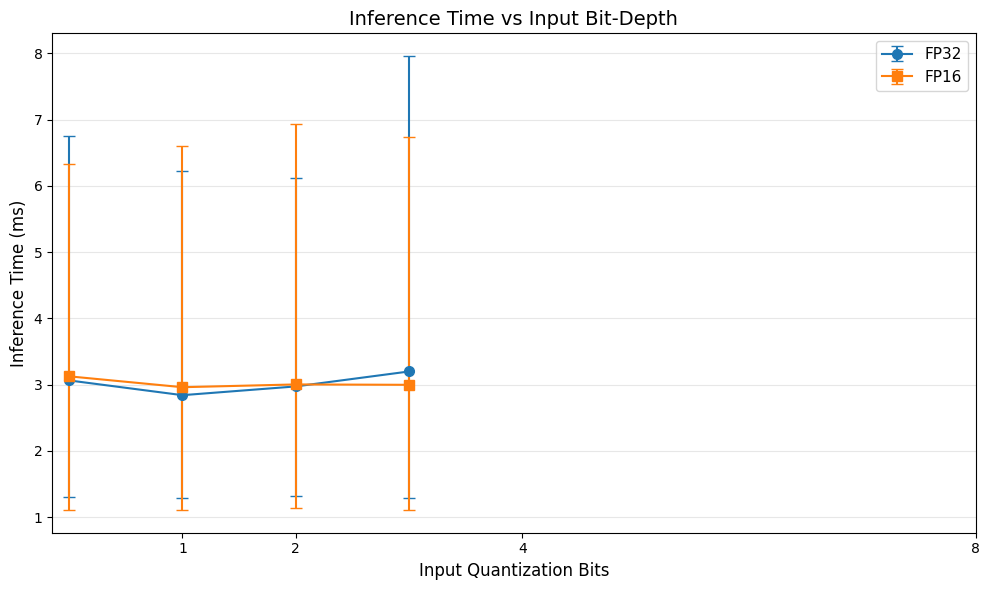

In [9]:
import matplotlib.pyplot as plt

runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter base conditions
base_filter = (df["cfg.backend"] == "pytorch") & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))

plt.figure(figsize=(10, 6))

bit_values = sorted(df[base_filter]["cfg.input_quant_bits"].unique())

for precision, marker in [("fp32", "o"), ("fp16", "s")]:
    df_filtered = df[base_filter & (df["cfg.model_precision"] == precision)].sort_values("cfg.input_quant_bits")
    avgs = df_filtered["res.infer_ms_avg"].values
    mins = df_filtered["res.infer_ms_min"].values
    maxs = df_filtered["res.infer_ms_max"].values
    x_vals = [list(bit_values).index(b) for b in df_filtered["cfg.input_quant_bits"].values]

    plt.errorbar(x_vals, avgs, yerr=[avgs - mins, maxs - avgs], marker=marker,
                 capsize=4, linewidth=1.5, markersize=7, label=precision.upper())

plt.xlabel("Input Quantization Bits", fontsize=12)
plt.ylabel("Inference Time (ms)", fontsize=12)
plt.title("Inference Time vs Input Bit-Depth", fontsize=14)
plt.xticks(bit_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [10]:
#accuracy is same for both fp16 and fp32